In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/football_cleaned.csv"
)

df["Match_Date"] = pd.to_datetime(df["Match_Date"])

In [41]:
result_counts = df["Match_Result"].value_counts()

print(result_counts)

Match_Result
Home Win    1589
Away Win    1547
Draw         664
Name: count, dtype: int64


In [42]:
result_percentage = (
    df["Match_Result"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(result_percentage)

Match_Result
Home Win    41.82
Away Win    40.71
Draw        17.47
Name: proportion, dtype: float64


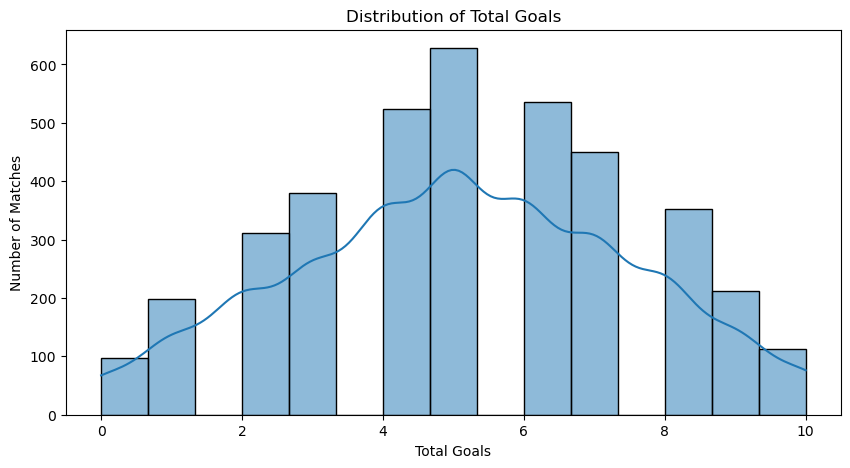

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Total_Goals"],
    bins=15,
    kde=True
)

plt.title("Distribution of Total Goals")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")

plt.show()


In [44]:
league_analysis = (
    df.groupby("League")
      .agg(
          Matches=("Match_Result", "count"),
          Avg_Goals=("Total_Goals", "mean"),
          Avg_Attendance=("Attendance", "mean")
      )
      .round(2)
)

display(league_analysis)

,Matches,Avg_Goals,Avg_Attendance
League,,,
Championship League,1276,5.09,33474.62
Cup Series,1265,5.06,35370.61
Premier Division,1259,5.16,33355.52


In [45]:
weather_analysis = (
    df.groupby("Weather")
      .agg(
          Matches=("Match_Result", "count"),
          Avg_Goals=("Total_Goals", "mean"),
          Avg_Attendance=("Attendance", "mean")
      )
      .round(2)
)

display(weather_analysis)

,Matches,Avg_Goals,Avg_Attendance
Weather,,,
Clear,994,5.06,33099.03
Cloudy,966,5.06,35145.45
Rainy,909,5.13,33876.56
Windy,931,5.17,34164.67


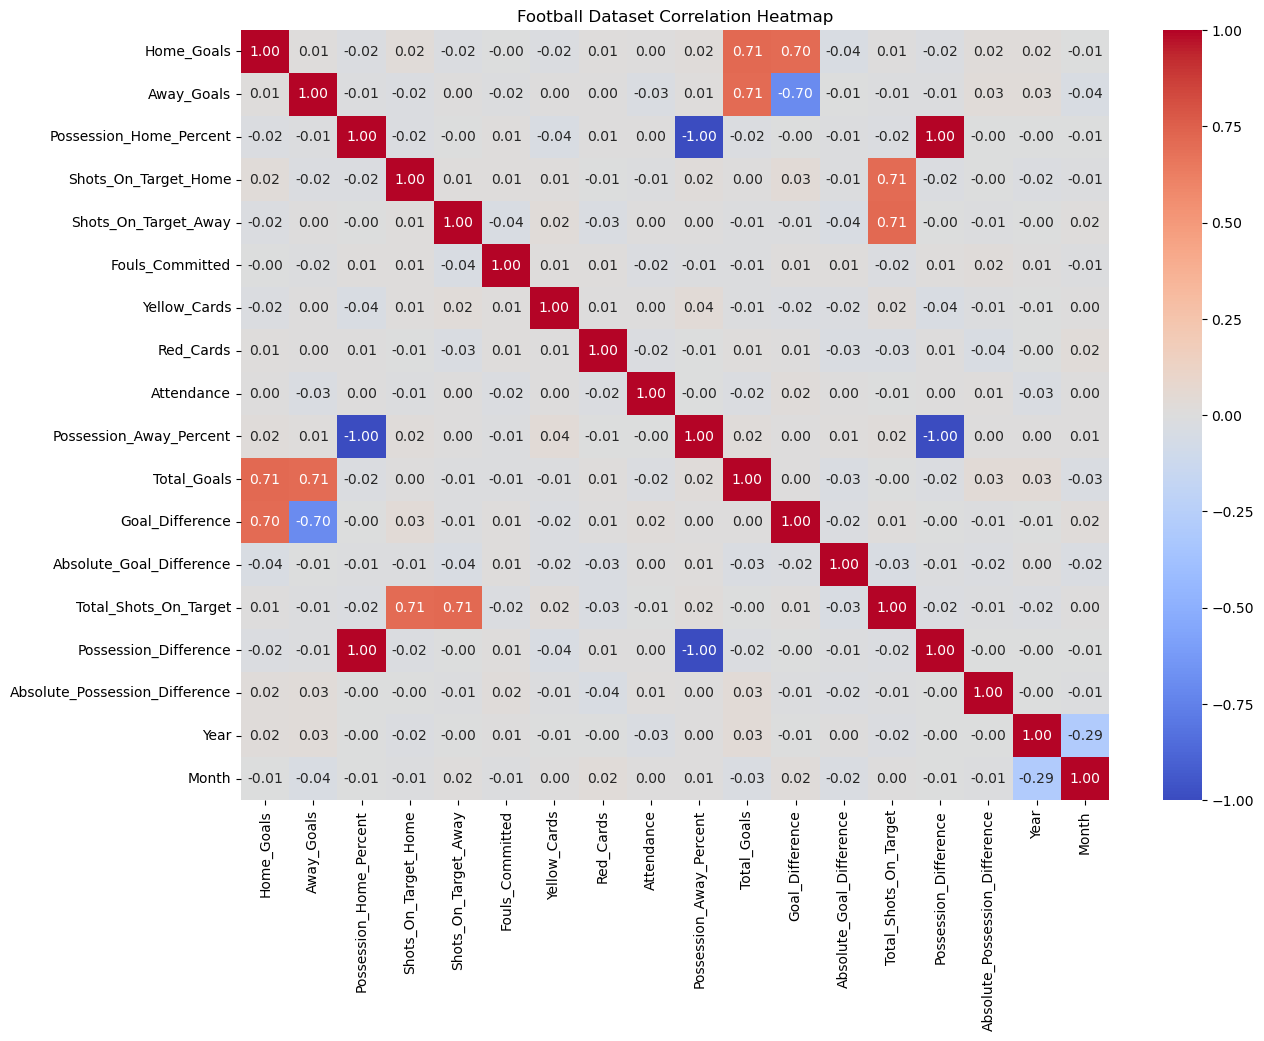

In [46]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Football Dataset Correlation Heatmap")
plt.show()

In [48]:
home_team = (
    df.groupby("Home_Team")
      .agg(
          Matches=("Home_Team", "count"),
          Goals_Scored=("Home_Goals", "sum"),
          Avg_Goals=("Home_Goals", "mean"),
          Avg_Possession=("Possession_Home_Percent", "mean"),
          Avg_Shots_On_Target=("Shots_On_Target_Home", "mean")
      )
      .round(2)
)

display(home_team)

,Matches,Goals_Scored,Avg_Goals,Avg_Possession,Avg_Shots_On_Target
Home_Team,,,,,
Bengaluru FC,391,1015,2.60,50.55,6.47
Chennai Titans,400,1075,2.69,49.29,7.06
Delhi Dynamos,379,973,2.57,49.71,7.16
Goa Sharks,401,1038,2.59,49.87,7.40
Hyderabad Falcons,360,854,2.37,50.45,6.72
Jaipur Lions,371,910,2.45,50.07,7.28
Kerala Blasters,407,1049,2.58,49.60,7.06
Kolkata Strikers,391,1009,2.58,49.32,7.00
Mumbai United,342,882,2.58,50.54,7.13


In [49]:
home_wins = (
    df[df["Match_Result"] == "Home Win"]
    .groupby("Home_Team")
    .size()
    .rename("Home_Wins")
)

home_team = home_team.join(home_wins)

home_team["Home_Wins"] = (
    home_team["Home_Wins"]
    .fillna(0)
)

home_team["Home_Win_Percentage"] = (
    home_team["Home_Wins"] /
    home_team["Matches"] * 100
).round(2)

display(home_team)

,Matches,Goals_Scored,Avg_Goals,Avg_Possession,Avg_Shots_On_Target,Home_Wins,Home_Win_Percentage
Home_Team,,,,,,,
Bengaluru FC,391,1015,2.60,50.55,6.47,167,42.71
Chennai Titans,400,1075,2.69,49.29,7.06,192,48.00
Delhi Dynamos,379,973,2.57,49.71,7.16,159,41.95
Goa Sharks,401,1038,2.59,49.87,7.40,161,40.15
Hyderabad Falcons,360,854,2.37,50.45,6.72,138,38.33
Jaipur Lions,371,910,2.45,50.07,7.28,144,38.81
Kerala Blasters,407,1049,2.58,49.60,7.06,168,41.28
Kolkata Strikers,391,1009,2.58,49.32,7.00,172,43.99
Mumbai United,342,882,2.58,50.54,7.13,143,41.81


In [51]:
team_stats = df.groupby("Home_Team").agg(
    Matches=("Home_Team", "count"),
    Avg_Goals=("Home_Goals", "mean"),
    
).sort_values("Avg_Goals", ascending=False)

print(team_stats.head(10))

                   Matches  Avg_Goals
Home_Team                            
Chennai Titans         400   2.687500
Bengaluru FC           391   2.595908
Goa Sharks             401   2.588529
Kolkata Strikers       391   2.580563
Mumbai United          342   2.578947
Kerala Blasters        407   2.577396
Delhi Dynamos          379   2.567282
Pune Warriors          358   2.505587
Jaipur Lions           371   2.452830
Hyderabad Falcons      360   2.372222


In [54]:
home_win_rate = (
    df["Match_Result"].eq("H")
    .mean() * 100
)

away_win_rate = (
    df["Match_Result"].eq("A")
    .mean() * 100
)

draw_rate = (
    df["Match_Result"].eq("D")
    .mean() * 100
)

print("Home Win:", home_win_rate)
print("Away Win:", away_win_rate)
print("Draw:", draw_rate)

Home Win: 0.0
Away Win: 0.0
Draw: 0.0


In [56]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    df["Home_Goals"],
    df["Away_Goals"],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.04054524662403193
P-value: 0.967659500389532
